In [2]:
using JSON
using Plots


In [3]:
# -----------------------------
# SALVATAGGIO (più flessibile)
# -----------------------------
function save_CCE_results(filename, x_pos, CCE_mean, CCE_std; params=nothing)

    results = Dict(
        "x_pos" => collect(x_pos),
        "CCE_mean" => CCE_mean,
        "CCE_std" => CCE_std
    )

    # aggiunge params solo se forniti
    if params !== nothing
        results["params"] = params
    end

    open(filename, "w") do f
        JSON.print(f, results, 4)
    end

    println("Salvato file: ", filename)
end


# -----------------------------
# LETTURA (robusta)
# -----------------------------
function load_CCE_results(filename)

    data = JSON.parsefile(filename)

    # --- caso 1: formato semplice (il tuo attuale)
    if haskey(data, "x_pos")
        x   = Float64.(data["x_pos"])
        cce = Float64.(data["CCE_mean"])
        err = Float64.(data["CCE_std"])
        params = haskey(data, "params") ? data["params"] : Dict()

    # --- caso 2: formato annidato
    elseif haskey(data, "data")
        d = data["data"]
        x   = Float64.(d["x_pos"])
        cce = Float64.(d["CCE_mean"])
        err = Float64.(d["CCE_std"])
        params = haskey(data, "params") ? data["params"] : Dict()

    else
        error("Formato JSON non riconosciuto")
    end

    return x, cce, err, params
end

load_CCE_results (generic function with 1 method)

# CONFRONTO GIOVANETTI vs MIO CODICE CON 1 Litio - size

In [39]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 1000 charges, 25 rep
xR, cceR, errR, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con il codice mio, dx = 20 um, 1000 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/My-uncomplete-model.json");

SystemError: SystemError: opening file "my model/My-uncomplete-model.json": No such file or directory

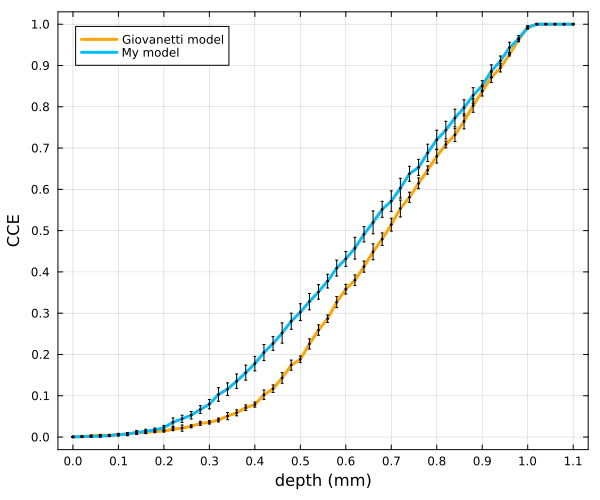

In [40]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1

plt = plot(xR.*10, cceR, lw=3, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Giovanetti model",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(xMM.*10, cceMM, lw=3, color=:deepskyblue, label = "My model")


plot!(
    xR.*10, cceR,
    yerr=errR,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false,
)


plot!(
    xMM.*10, cceMM,
    yerr=errMM,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false
)

savefig(plt, "plot/CCE_comparison.png")
display(plt)

# CONFRONTO MIO MODELLO CON 1 LITIO vs DIEMENSIONE LITIO RANDOMICA

In [43]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
x_1Li, cce_1Li, err_1Li, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il codice mio, dx = 20 um, 1000 charges, 25 rep
x_RLi, cce_RLi, err_RLi, params_loaded = load_CCE_results("my model/json-CCE-file/random-Li.json");


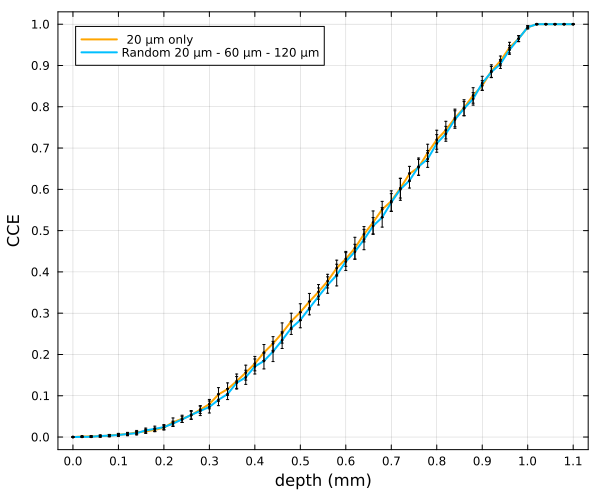

In [44]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1

plt = plot(x_1Li.*10, cce_1Li, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label=" 20 μm only",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(x_RLi.*10, cce_RLi, lw=2, color=:deepskyblue, label = "Random 20 μm - 60 μm - 120 μm")


plot!(
    x_1Li.*10, cce_1Li,
    yerr=err_1Li,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false,
)


plot!(
    x_RLi.*10, cce_RLi,
    yerr=err_RLi,
    seriestype=:scatter,
    color=:black,
    marker=:circle,
    ms=1.5,
    label=false
)

savefig(plt, "plot/CCE_comparison_different_Li_sizes.png")
display(plt)

# Comparison my model + reald diffusivity

In [ ]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il mio codice + la diffusività che  dipende dalla posizione, dx = 20 um, 1000 charges, 25 rep
x_D, cce_D, err_D, params_loaded = load_CCE_results("my model/json-CCE-file/Diffusivity_CCE.json");


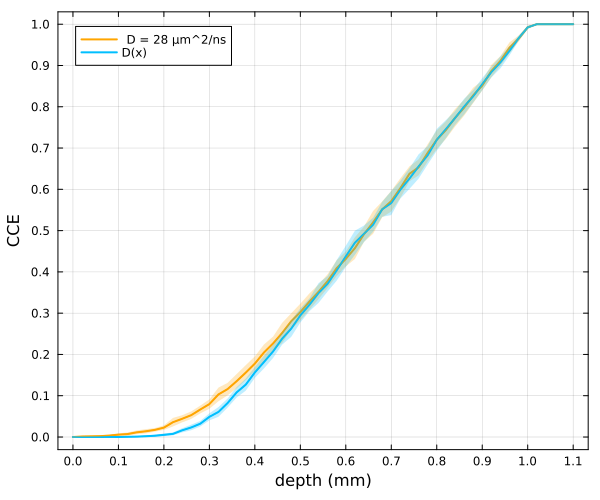

In [ ]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label=" D = 28 μm^2/ns",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(600, 500)
)
plot!(x_D.*10, cce_D, lw=2, color=:deepskyblue, label = "D(x)")


plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:orange,
        label=false
)


plot!(
    x_D.*10, 
    cce_D,
        ribbon=err_D,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)


savefig(plt, "plot/CCE_comparison_mymodel_D_real.png")
display(plt)

# Comparison my model + Giova unif + Giov erf

In [50]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con Giovanetti unif(0.5%) , 500 charges, 50 rep
x_05, cce_05, err_05, params_loaded = load_CCE_results("Radford/Radford_CCE.json");
# questa è la curva CCE fatta con Giovanetti + 1.5*erf , 500 charges, 25 rep
x_erf, cce_erf, err_erf, params_loaded = load_CCE_results("my model/json-CCE-file/erf-1.5%.json");


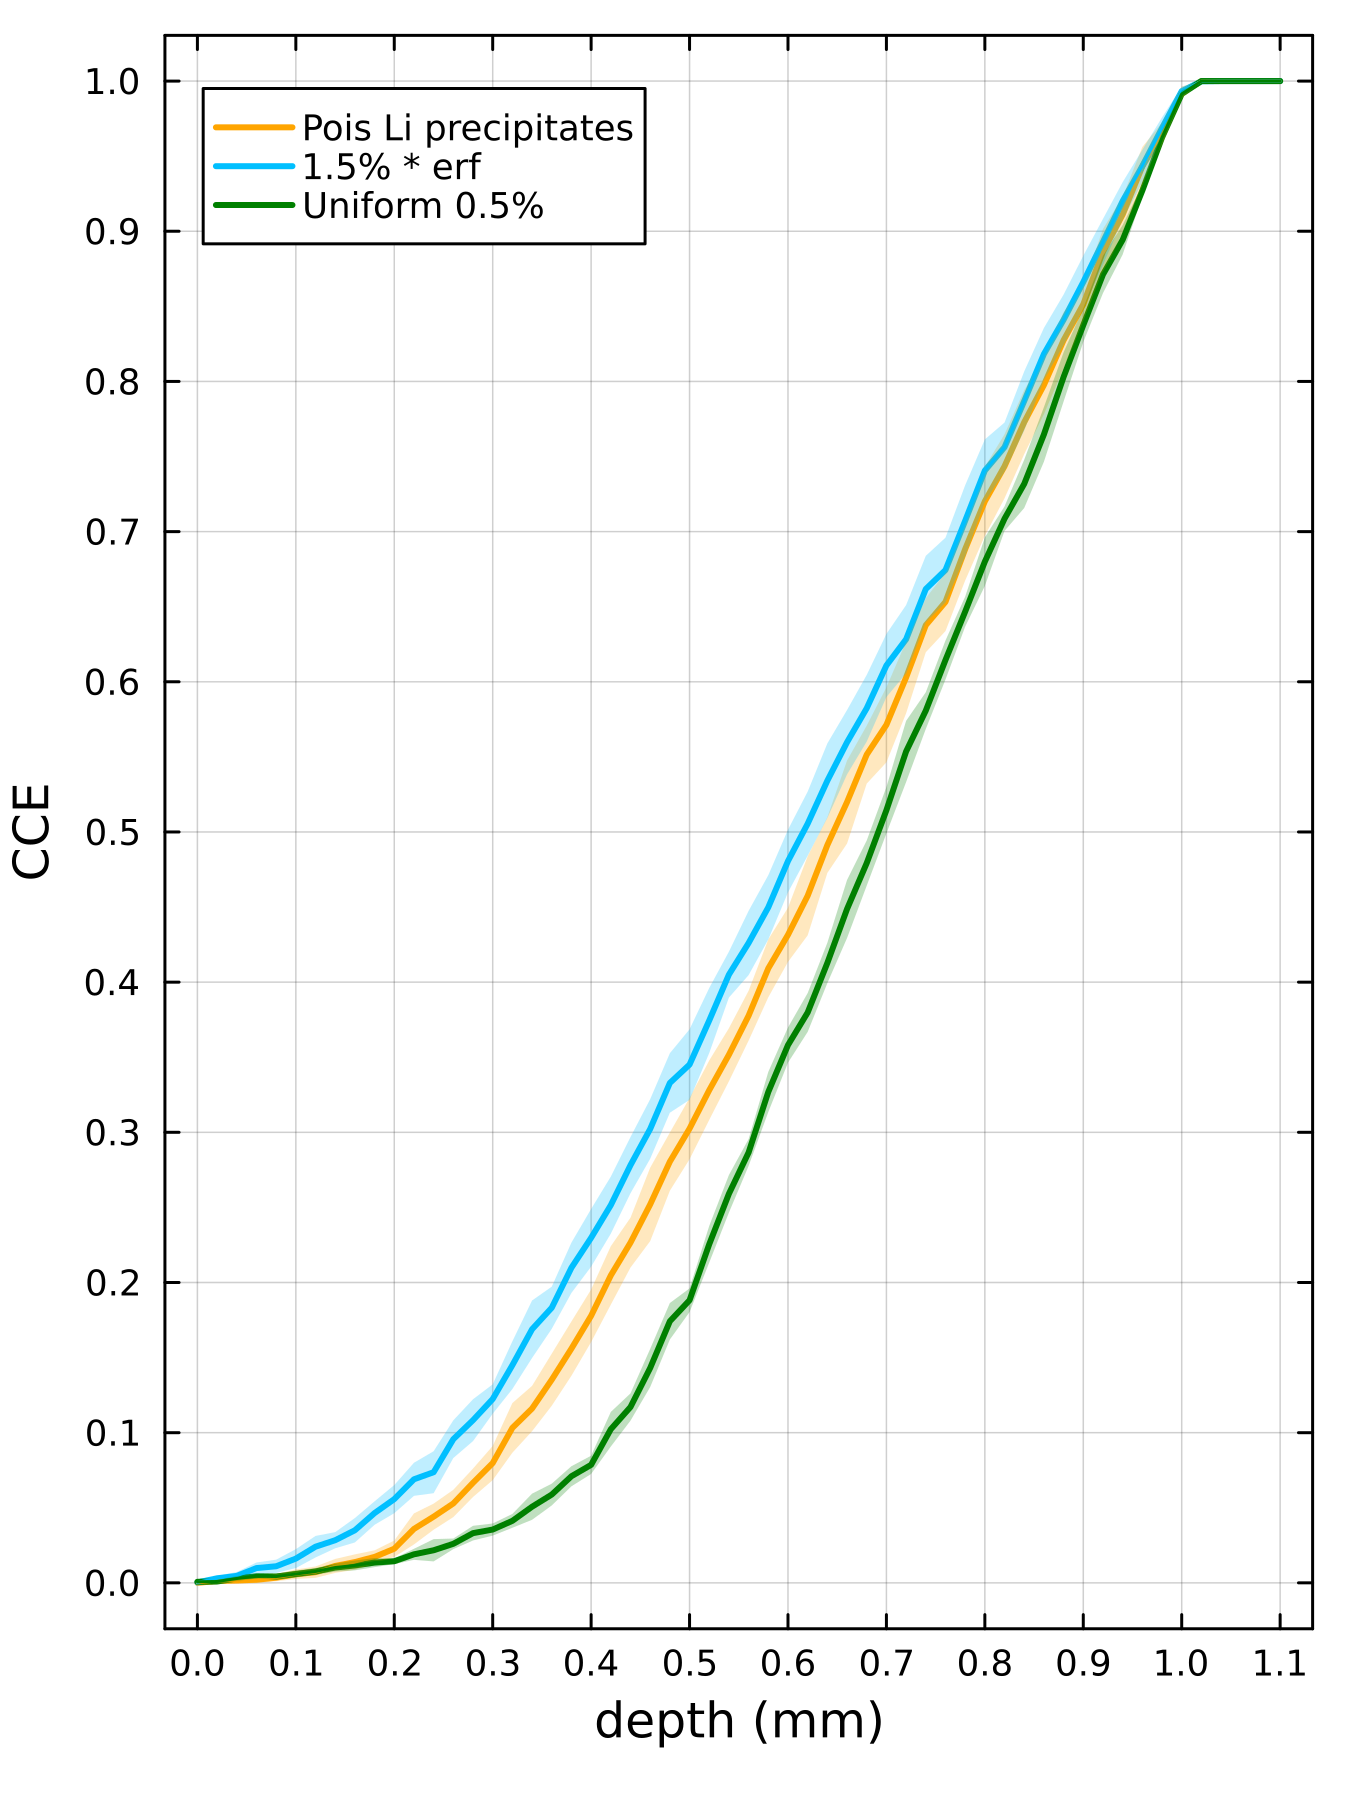

In [54]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:orange,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(450, 600), dpi = 300
)
plot!(x_erf.*10, cce_erf, lw=2, color=:deepskyblue, label = "1.5% * erf")
plot!(x_05.*10, cce_05, lw=2, color=:green, label = "Uniform 0.5%")


plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:orange,
        label=false
)


plot!(
    x_erf.*10, 
    cce_erf,
        ribbon=err_erf,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_05.*10, 
    cce_05,
        ribbon=err_05,
        fillalpha=0.25,
        color=:green,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_Giov05_giova1.5%erf.png")
display(plt)

# My model + Claudia tau(x)

In [59]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con codice Claudia-stile ma avendo il tempo che dipende dalla posizione , charge = 500, rep = 25
filename = "my model/json-CCE-file/tau_model_results_1,6e-11.json"
data = JSON.parsefile(filename)
x_τ = Float64.(data["x_pos"])
alpha = "1.6e-11"  
cce_τ = Float64.(data["alphas"][alpha]["CCE_mean"])
err_τ  = Float64.(data["alphas"][alpha]["CCE_std"]);

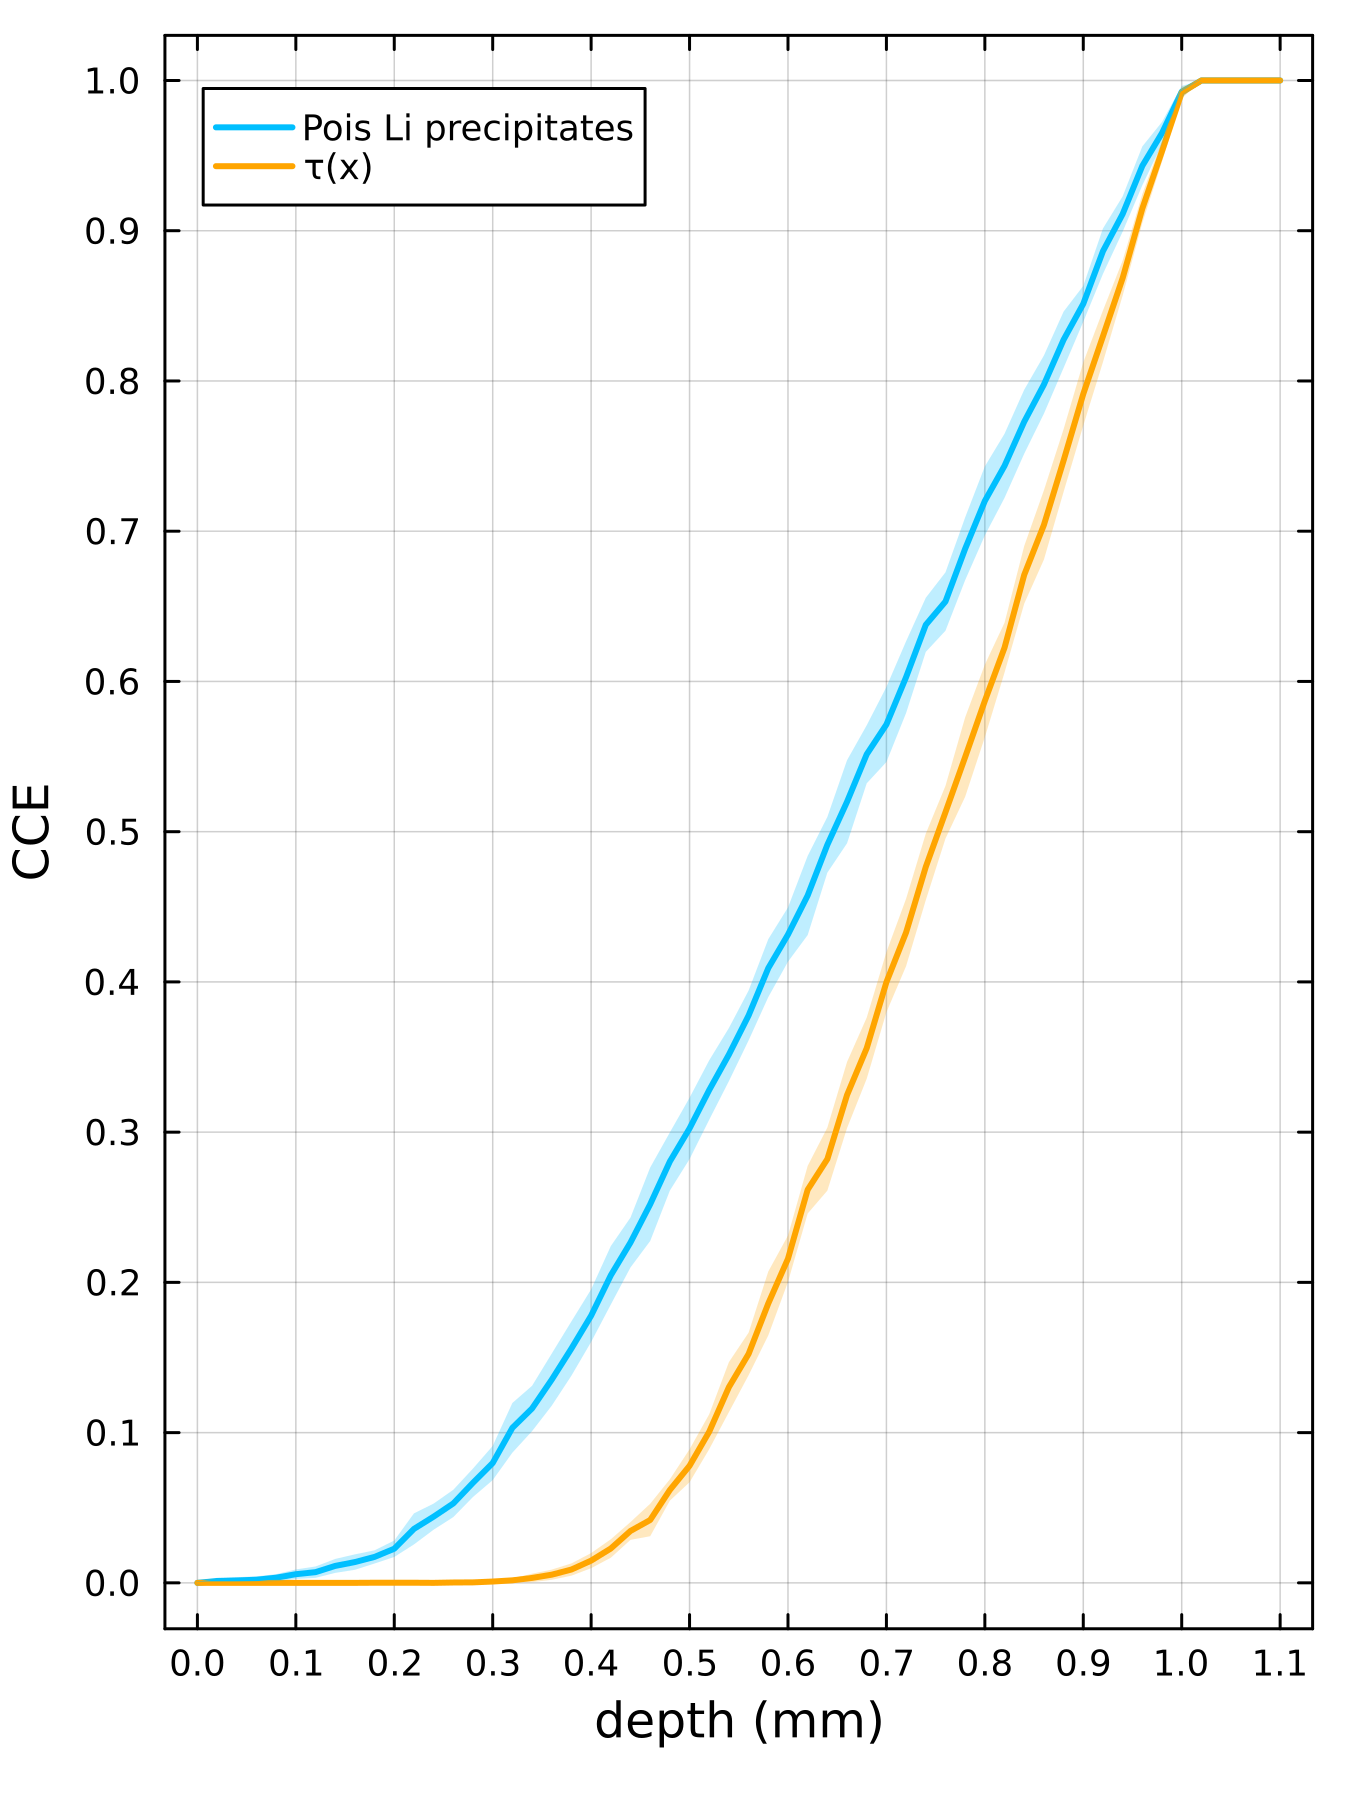

In [61]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(450, 600), dpi = 300
)
plot!(x_erf.*10, cce_τ, lw=2, color=:orange, label = "τ(x)")

plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_τ.*10, 
    cce_τ,
        ribbon=err_τ,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_tau(x).png")
display(plt)

# COmparison My model + my model with constant tau

In [63]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il mio metodo ma con una probabilità costante di trapping , 500 charges, 50 rep
x_800ns, cce_800ns, err_800ns, params_loaded = load_CCE_results("my model/json-CCE-file/Point-Li-and-const-tau-800ns.json");


bha secondo me non ha molto senso... oerchè dovrei avere una probabilità che dipende dal time-stamp? dovrebbe essere una prpbabilità che dipenda al più dalla dimensione del precipitato... ma così non è tenere ijnn considerazione due volte lo stesso fattore geometrico?

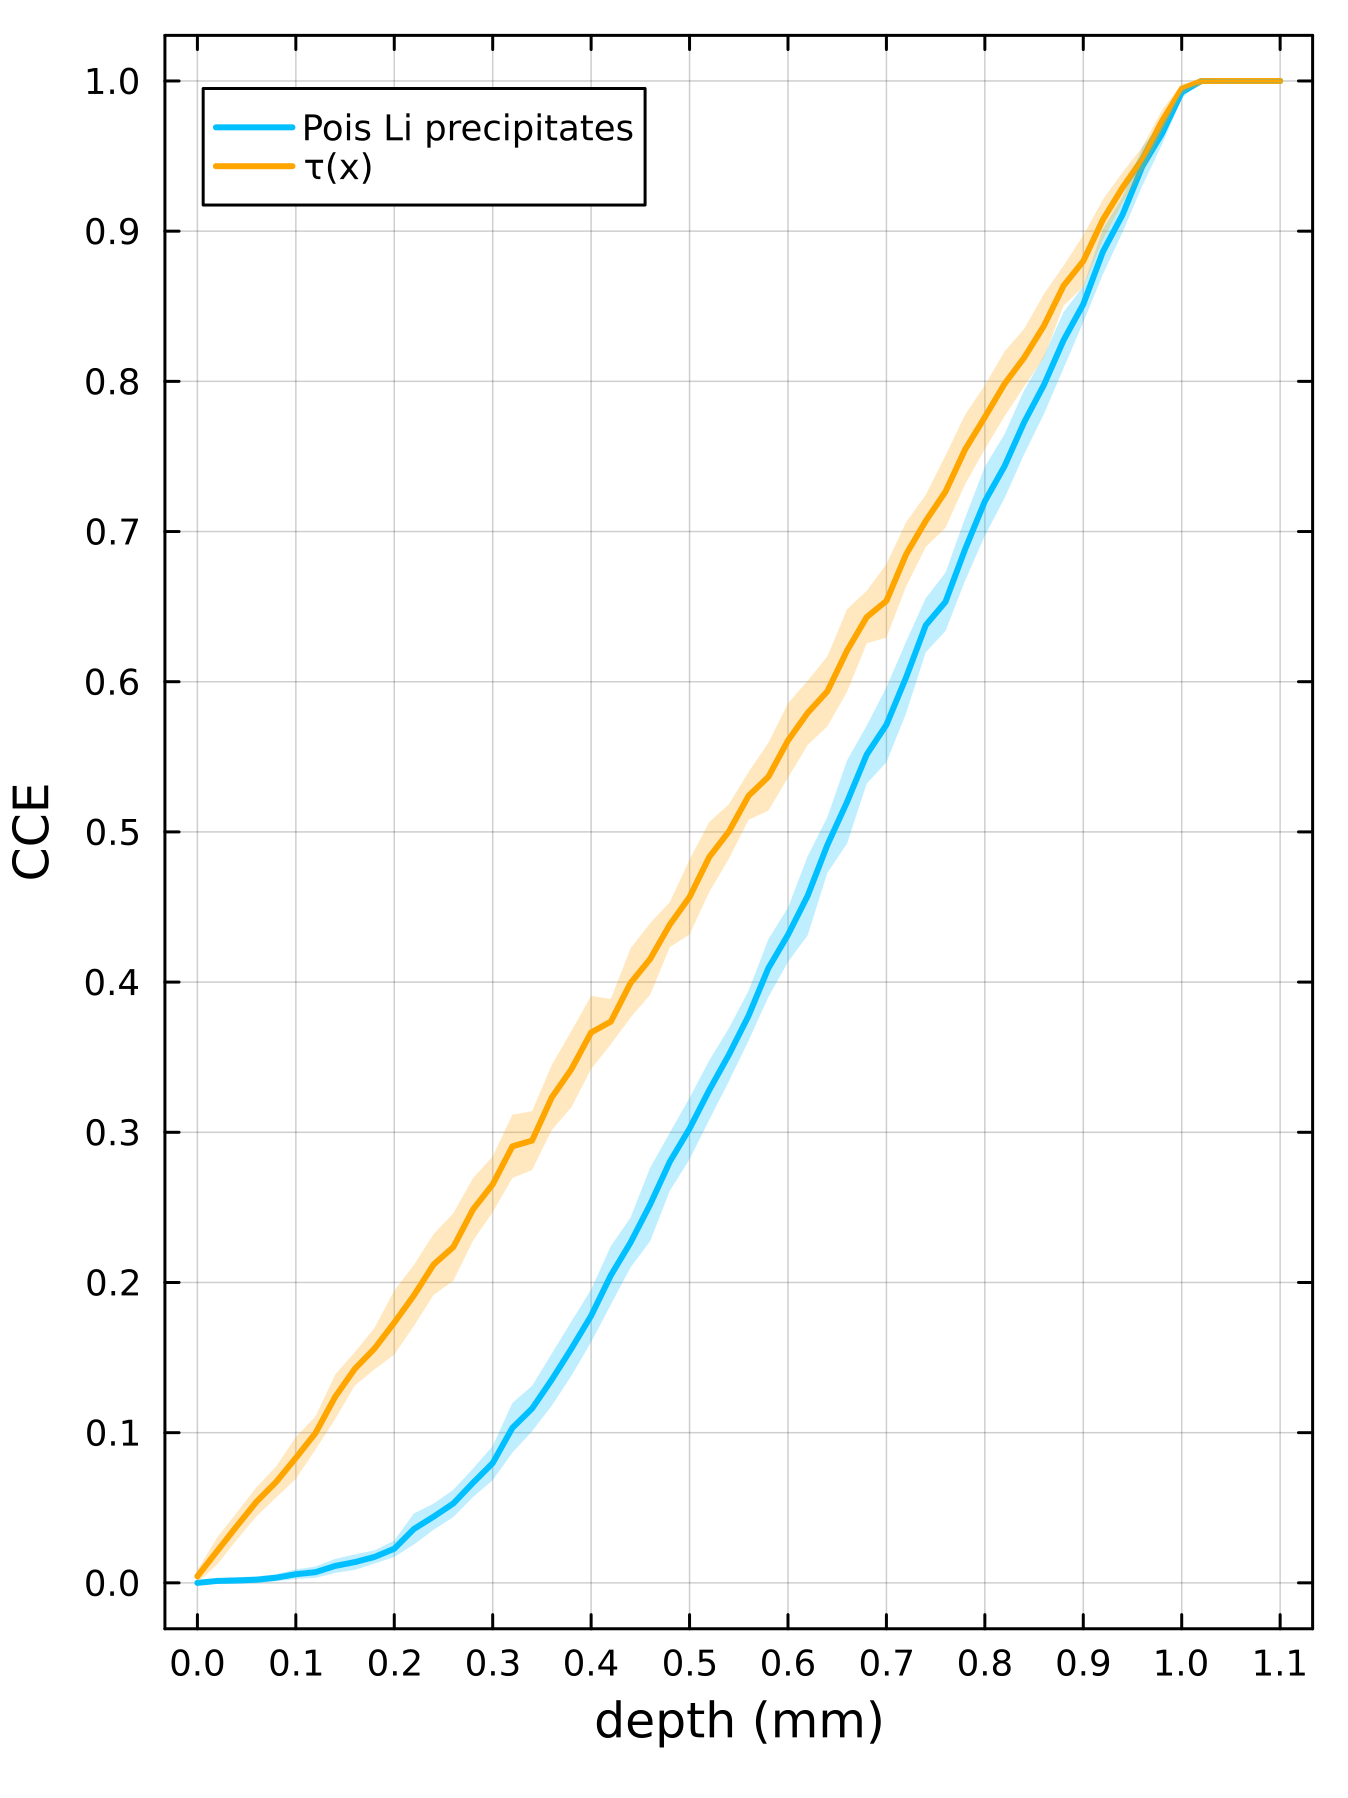

In [ ]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1



plt = plot(xMM.*10, cceMM, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), frame=:box, size=(450, 600), dpi = 300
)
plot!(x_800ns.*10, cce_800ns, lw=2, color=:orange, label = "τ = 800 ns")

plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_800ns.*10, 
    cce_800ns,
        ribbon=err_800ns,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_MM+constant tau.png")
display(plt)

# My model + My model RDR

In [4]:
# questa è la curva CCE fatta con il codice di gioavnetti, dx = 20 um, 500 charges, 25 rep
xMM, cceMM, errMM, params_loaded = load_CCE_results("my model/json-CCE-file/My-uncomplete-model.json");
# questa è la curva CCE fatta con il mio metodo ma con RDR , 500 charges, 25 rep
x_RDR, cce_RDR, err_RDR, params_loaded = load_CCE_results("my model/json-CCE-file/My-model+RDR.json");


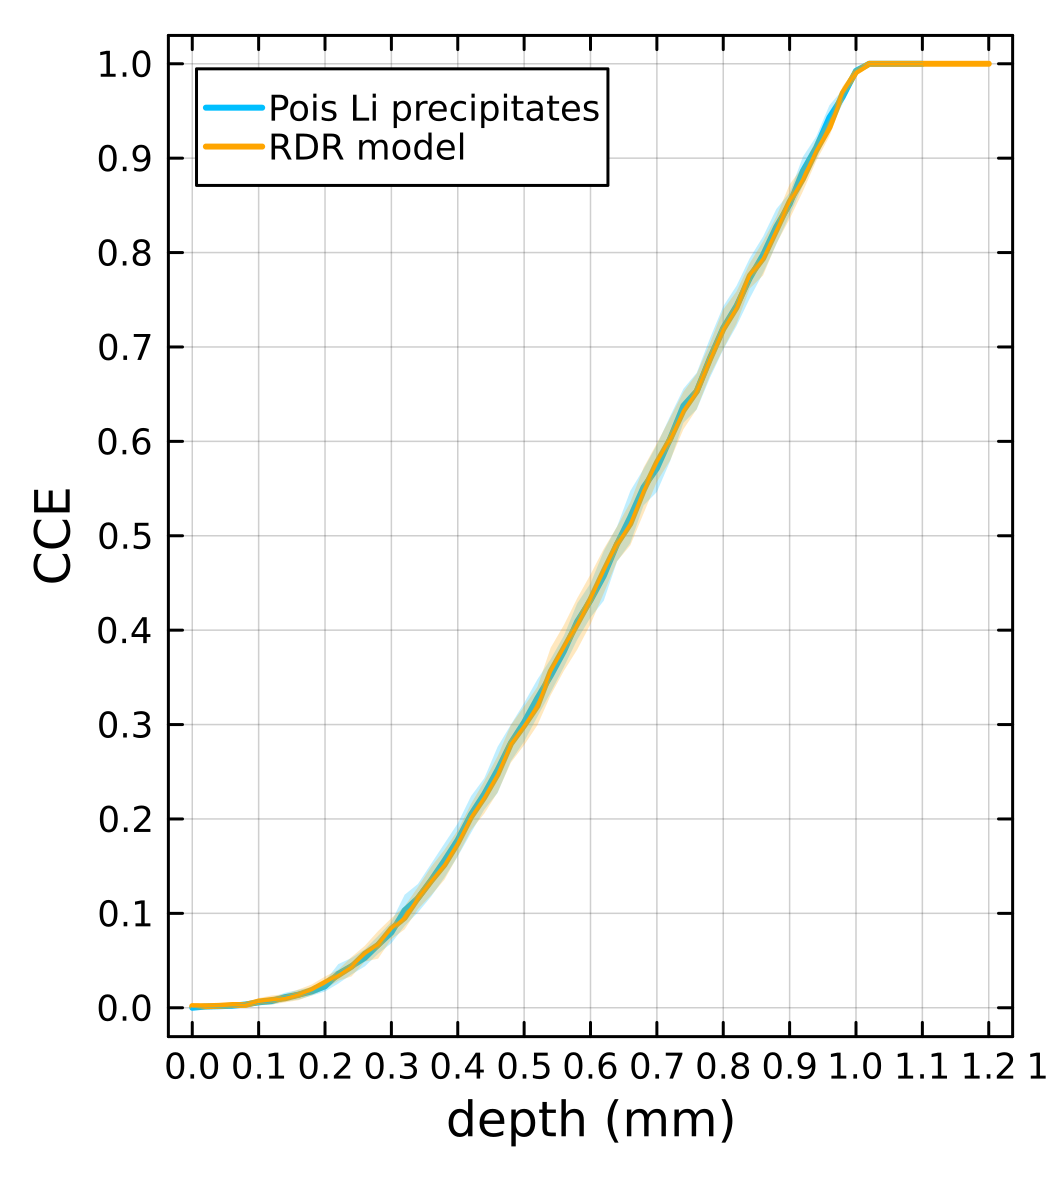

In [8]:
xticks_positions = 0:0.1:1.5
yticks_positions = 0:0.1:1


plt = plot(xMM.*10, cceMM, lw=2, color=:deepskyblue,
    xlabel="depth (mm)", ylabel="CCE", label="Pois Li precipitates",
    xticks=(xticks_positions, string.(round.(xticks_positions, digits=2))),
    yticks=(yticks_positions, string.(round.(yticks_positions, digits=1))), 
    frame=:box, size=(350, 400), dpi = 300
)
plot!(x_RDR.*10, cce_RDR, lw=2, color=:orange, label = "RDR model")

plot!(
    xMM.*10, 
    cceMM,
        ribbon=errMM,
        fillalpha=0.25,
        color=:deepskyblue,
        label=false
)
plot!(
    x_RDR.*10, 
    cce_RDR,
        ribbon=err_RDR,
        fillalpha=0.25,
        color=:orange,
        label=false
)



savefig(plt, "plot/CCE_comparison_MM_MM+RDR.png")
display(plt)